#03-ANÁLISIS EXPLORATORIO DE DATOS

In [13]:
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos profesionales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos
streaming_users = pd.read_csv(
    r"C:\Users\jorge leandro\OneDrive\Desktop\proyecto_final_md\data\processed\streaming_users_clean.csv"
)


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# ANÁLISIS UNIVARIADO

Variable Numérica: monthly_watch_time_mins
¿Cuál es el nivel general de engagement de la base de usuarios y existen patrones de desinterés (bajo consumo de minutos)?

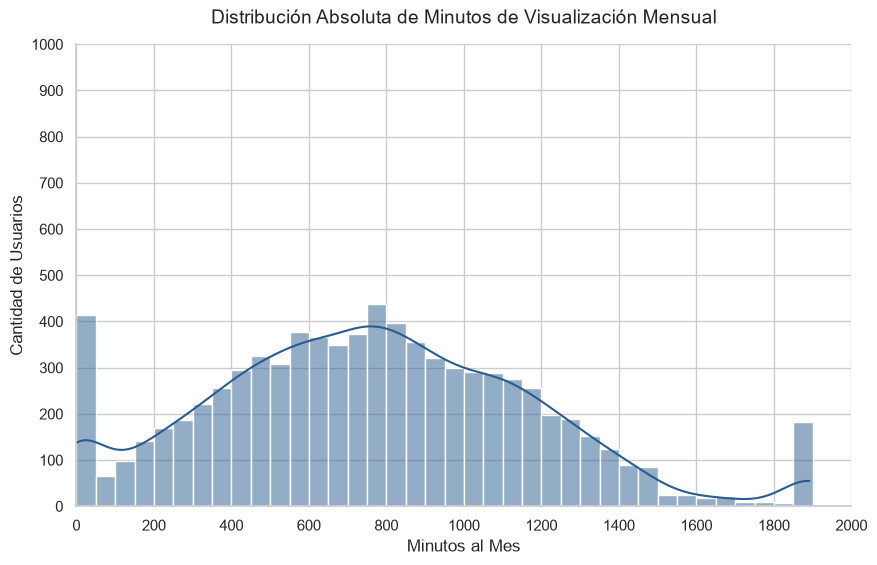

In [16]:
# Graficamos configurando el rango fijo en ambos ejes
sns.histplot(
    data=streaming_users, 
    x='monthly_watch_time_mins', 
    kde=True, 
    color='#2b5c8f',
    bins=40,               # Cantidad de barras óptima para este rango
    binrange=(0, 2000)     # Fuerza a las barras a distribuirse entre 0 y 2000
)

# Ajuste y personalización del Eje X (Minutos)
plt.xlim(0, 2000)
plt.xticks(np.arange(0, 2200, 200))

# Ajuste y personalización del Eje Y (Cantidad de Usuarios de 0 a 1000)
plt.ylim(0, 1000)
plt.yticks(np.arange(0, 1100, 100)) # Saltos de 100 en 100 para dar claridad visual

# Limpieza estética del gráfico (remueve los bordes superior y derecho)
sns.despine()

plt.title('Distribución Absoluta de Minutos de Visualización Mensual', fontsize=14, pad=15)
plt.xlabel('Minutos al Mes', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.show()

Interpretación:El nivel general de engagement es alto y saludable. La gran mayoría de los usuarios se concentra en un consumo activo de entre 400 y 1,200 minutos mensuales, manteniendo un promedio de uso constante.

Sin embargo, sí existe un patrón de desinterés crítico:

Los usuarios "fantasma" : Hay un grupo alarmante de más de 400 clientes que consumen casi cero minutos al mes. Pagan la suscripción pero no usan la plataforma. Representan un peligro inminente de cancelación y requieren campañas urgentes de reactivación.
En el extremo opuesto, hay otro comportamiento atípico con casi 200 súper usuarios clavados en los 1,900 minutos, lo que marca el límite máximo de consumo o un tope en el registro del sistema.

Variable Categórica: subscription_plan
¿Cómo está distribuida la estructura de suscripciones de la plataforma y cuál es el plan dominante?

C:\Users\jorge leandro\AppData\Local\Temp\ipykernel_22940\2037406807.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


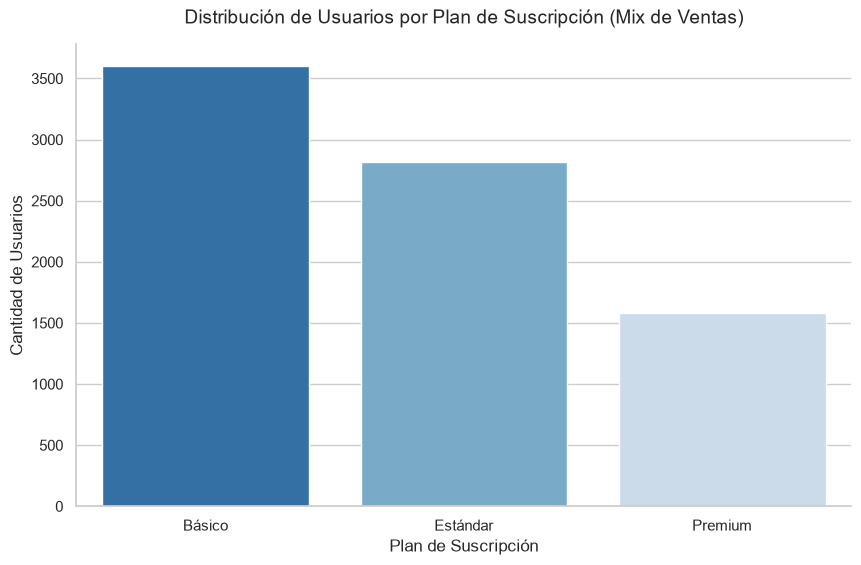

In [15]:
# Graficamos la distribución utilizando el dataframe limpio
sns.countplot(
    data=streaming_users, 
    x='subscription_plan', 
    order=streaming_users['subscription_plan'].value_counts().index, 
    palette='Blues_r'
)

# Ajustes estéticos profesionales
sns.despine()

plt.title('Distribución de Usuarios por Plan de Suscripción (Mix de Ventas)', fontsize=14, pad=15)
plt.xlabel('Plan de Suscripción', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.show()

La estructura de suscripciones de la plataforma presenta una distribución piramidal escalonada descendente, donde la base de usuarios decrece a medida que aumenta el valor del nivel de suscripción.

El plan dominante es el Básico, el cual lidera ampliamente el mix de ventas al concentrar a más de 3,500 usuarios. Le sigue en orden de importancia el plan Estándar con aproximadamente 2,800 usuarios y, finalmente, el plan Premium con cerca de 1,600 usuarios.

Esta configuración refleja que la estrategia actual del negocio está fuertemente traccionada por el volumen de captación en su escala de entrada económica.

# ANÁLISIS BIVARIADO
Variable Numérica vs Categórica: subscription_plan vs. monthly_watch_time_mins
¿Los usuarios que pagan por planes más caros (Premium) consumen significativamente más contenido, justificando el valor de su suscripción?

C:\Users\jorge leandro\AppData\Local\Temp\ipykernel_22940\3502046359.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=streaming_users, x='subscription_plan', y='monthly_watch_time_mins', palette='Set2')


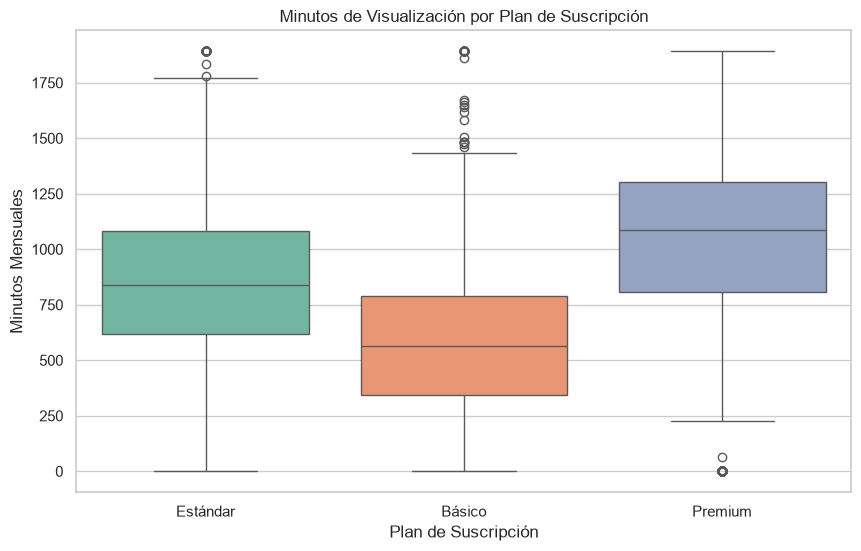

In [17]:
sns.boxplot(data=streaming_users, x='subscription_plan', y='monthly_watch_time_mins', palette='Set2')
plt.title('Minutos de Visualización por Plan de Suscripción')
plt.xlabel('Plan de Suscripción')
plt.ylabel('Minutos Mensuales')
plt.show()

Interpretación: Sí, los usuarios Premium consumen significativamente más contenido, justificando el valor de su suscripción.

El gráfico de caja de cada plan muestra un comportamiento muy claro:

Consumo superior (Premium): La caja del plan Premium está notablemente más alta que las demás. Su mediana (la línea central de la caja) se ubica cerca de los 1,100 minutos mensuales, superando por mucho los aproximadamente 850 minutos del plan Estándar y los 550 minutos del plan Básico.

Comportamiento escalonado: Existe una relación directa entre el precio del plan y los minutos de visualización. A medida que el plan es más caro, el rango de consumo típico (el cuerpo de la caja) se desplaza hacia arriba.

Menos usuarios "fantasma": El plan Premium muestra su límite inferior más arriba que el resto, lo que significa que tiene una menor proporción de usuarios con consumo bajo en comparación con el plan Básico, donde el grueso de los usuarios consume mucho menos.

Los usuarios que pagan más demuestran con su tiempo de reproducción que le sacan un mayor provecho a la plataforma.

Numérica vs. Numérica: age vs. customer_support_tickets
 ¿Existe alguna fricción demográfica en la plataforma? ¿Los usuarios mayores generan más tickets de soporte debido a problemas de usabilidad técnica?

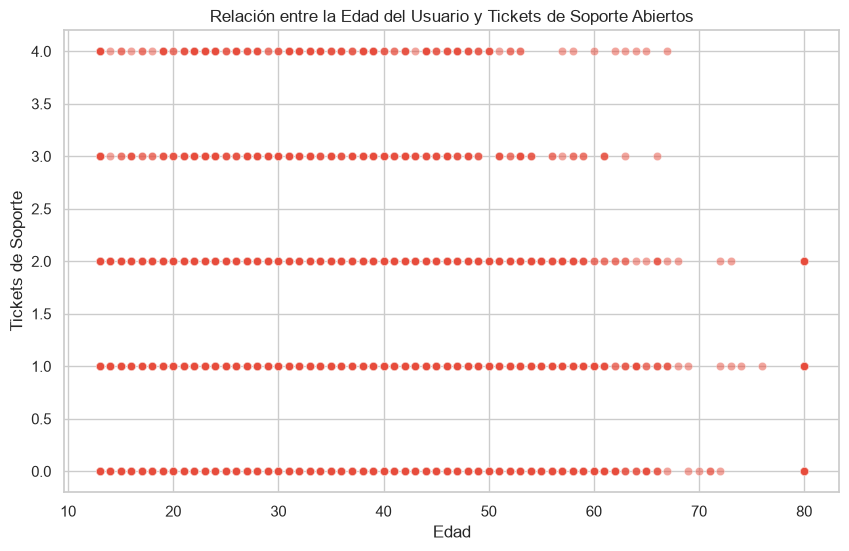

In [18]:
sns.scatterplot(data=streaming_users, x='age', y='customer_support_tickets', alpha=0.5, color='#e74c3c')
plt.title('Relación entre la Edad del Usuario y Tickets de Soporte Abiertos')
plt.xlabel('Edad')
plt.ylabel('Tickets de Soporte')
plt.show()

Interpretación: No, no parece existir una fricción demográfica vinculada a la edad, ni evidencia de que los usuarios mayores generen más tickets de soporte.

El gráfico de dispersión muestra un comportamiento muy particular que destruye esa hipótesis:

Distribución homogénea y plana: Los puntos se distribuyen en líneas horizontales perfectas desde los 13 hasta los 50-60 años para cualquier cantidad de tickets (0, 1, 2, 3 o 4). No hay una pendiente ascendente a medida que aumenta la edad.

Menor densidad en edades avanzadas: A partir de los 55-60 años, los puntos se vuelven más transparentes y dispersos, lo que refleja simplemente que hay menos usuarios de esa edad en la plataforma, no que tengan más problemas. De hecho, los niveles altos de soporte (3 y 4 tickets) casi desaparecen en los mayores de 70 años.

Falta de correlación: La cantidad de reclamos parece ser totalmente independiente de los años que tenga el usuario. Alguien de 20 años tiene las mismas probabilidades de abrir 0 o 4 tickets que alguien de 50.

Conclusión: Los problemas que disparan la apertura de tickets de soporte están afectando a toda la base de clientes por igual (pueden ser fallas de red, problemas de facturación o caídas del servicio), descartando por completo que se trate de una barrera de usabilidad tecnológica asociada a la edad.

# Análisis Multivariado
Relación Compleja: age,subscription_plan y monthly_watch_time_mins
¿Cuál es el perfil del usuario con mayor riesgo de abandono según su combinación de plan, edad y consumo?

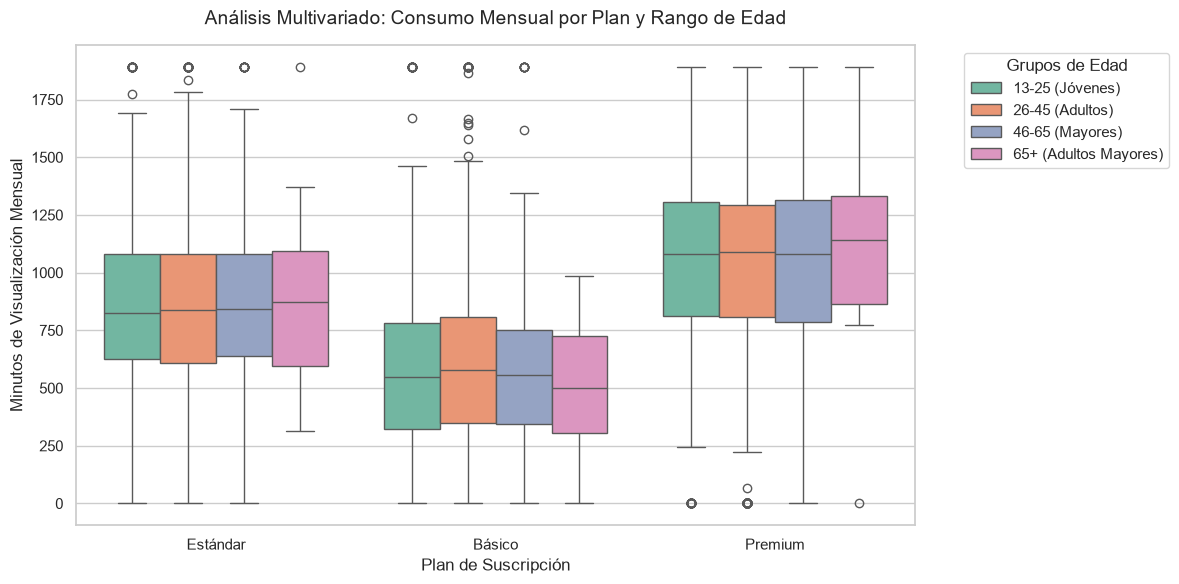

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos rangos de edad para poder segmentar mejor en el gráfico
streaming_users['rango_edad'] = pd.cut(
    streaming_users['age'], 
    bins=[0, 25, 45, 65, 100], 
    labels=['13-25 (Jóvenes)', '26-45 (Adultos)', '46-65 (Mayores)', '65+ (Adultos Mayores)']
)

# 2. Graficamos el cruce multivariado
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=streaming_users,
    x='subscription_plan',
    y='monthly_watch_time_mins', # Reemplaza por el nombre exacto de tu columna de minutos
    hue='rango_edad',
    palette='Set2'
)

plt.title('Análisis Multivariado: Consumo Mensual por Plan y Rango de Edad', fontsize=14, pad=15)
plt.xlabel('Plan de Suscripción', fontsize=12)
plt.ylabel('Minutos de Visualización Mensual', fontsize=12)
plt.legend(title='Grupos de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Interpretación: El perfil de usuario con mayor riesgo de abandono está compuesto por los Adultos Mayores (65+ años) y Mayores (46-65 años) que están suscritos al Plan Básico.

El gráfico fundamenta esta conclusión a través de tres hallazgos clave:

El Plan Básico es la zona de peligro: Independientemente de la edad, todas las cajas del plan Básico están significativamente más abajo en la escala de consumo que las de los planes Estándar y Premium. Sus usuarios promedian apenas entre 500 y 570 minutos mensuales.

La edad profundiza el desinterés en el plan económico: Al mirar en detalle el plan Básico, se observa una clara tendencia decreciente conforme avanza la edad. La caja de los Adultos Mayores (65+ años, color rosa) es la más baja de todo el gráfico, con una mediana que roza los 500 minutos y un límite inferior que cae drásticamente hacia cero. El grupo de 46-65 años (azul) muestra un comportamiento casi igual de deprimido.

El contraste con el segmento Premium: Mientras que en el plan Premium los adultos mayores (rosa) son justamente los que más contenido consumen (su mediana supera los 1,100 minutos), en el plan Básico son los que menos lo usan.

Conclusión estratégica: La combinación de la usabilidad o limitaciones del Plan Básico junto con segmentos de edad avanzada (46 a 65+ años) genera una sinergia que desploma el engagement. Este es el perfil "fantasma" que acumula el riesgo inminente de cancelación y hacia donde el equipo de marketing debe dirigir las estrategias de retención.